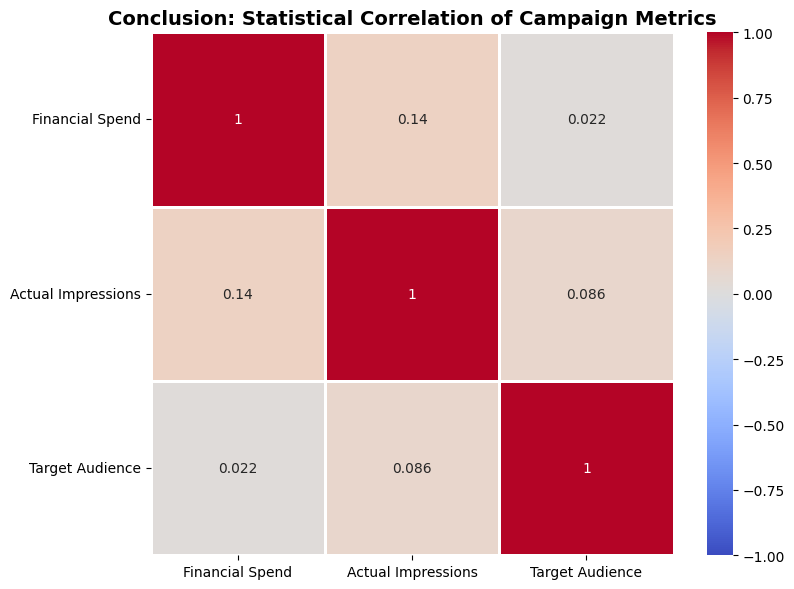

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re


df_clean = pd.read_csv("FINAL_facebook_ads_dataset.csv")


def get_average_value(size_string):
    if pd.isna(size_string): 
        return np.nan
        

    numbers = re.findall(r'\d+', str(size_string))
    

    if len(numbers) >= 2:
        return (float(numbers[0]) + float(numbers[1])) / 2
    
    elif len(numbers) == 1:
        return float(numbers[0])
        
    return np.nan


df_clean['spend_clean'] = df_clean['spend'].apply(get_average_value)
df_clean['impressions_clean'] = df_clean['impressions'].apply(get_average_value)
df_clean['audience_clean'] = df_clean['estimated_audience_size'].apply(get_average_value)
# =======================================================


numeric_cols = df_clean[['spend_clean', 'impressions_clean', 'audience_clean']]

# Calculate the correlation matrix
corr_matrix = numeric_cols.corr()

# 3. Plot the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=1,
    square=True
)

plt.title('Conclusion: Statistical Correlation of Campaign Metrics', fontsize=14, fontweight='bold')

plt.xticks(ticks=[0.5, 1.5, 2.5], labels=['Financial Spend', 'Actual Impressions', 'Target Audience'], rotation=0)
plt.yticks(ticks=[0.5, 1.5, 2.5], labels=['Financial Spend', 'Actual Impressions', 'Target Audience'], rotation=0)

plt.tight_layout()
plt.show()